# Walmart Demand Forecasting
## Notebook 04: Forecasting Model Development
## Objectives
Develop and compare forecasting models to predict Walmart's weekly sales.
### Dataset
- walmart_features.csv
### Tasks
- Load the processed feature dataset.
- Split the data using a time-based validation strategy.
- Establish baseline forecasting models.
- Train and compare machine learning models.
- Analyze feature importance.
- Generate weekly sales predictions.
### Expected Output
By the end of this notebook, we will have one or more forecasting models capable of predicting weekly sales. Model performance will be compared against baseline approaches to determine whether machine learning provides meaningful improvements in forecasting accuracy.

#1. Load and check data

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent

PROCESSED_PATH = PROJECT_ROOT / "data" / "processed"

df = pd.read_csv(
    PROCESSED_PATH / "walmart_features.csv",
    parse_dates=["Date"]
)
df.head()

,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,...,Type,Size,Year,Month,Week,lag_1,lag_2,lag_4,rolling_mean_4,rolling_std_4
0,1,1,2010-03-05,21827.90,46.50,2.625,0.0,0.0,0.0,0.0,...,A,151315,2010,3,9,19403.54,41595.55,24924.50,32990.7700,12832.106391
1,1,1,2010-03-12,21043.39,57.79,2.667,0.0,0.0,0.0,0.0,...,A,151315,2010,3,10,21827.90,19403.54,46039.49,32216.6200,13554.047185
2,1,1,2010-03-19,22136.64,54.58,2.720,0.0,0.0,0.0,0.0,...,A,151315,2010,3,11,21043.39,21827.90,41595.55,25967.5950,10467.484020
3,1,1,2010-03-26,26229.21,51.45,2.732,0.0,0.0,0.0,0.0,...,A,151315,2010,3,12,22136.64,21043.39,19403.54,21102.8675,1222.784968
4,1,1,2010-04-02,57258.43,62.27,2.719,0.0,0.0,0.0,0.0,...,A,151315,2010,4,13,26229.21,22136.64,21827.90,22809.2850,2325.929203


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 408436 entries, 0 to 408435
Data columns (total 24 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Store           408436 non-null  int64         
 1   Dept            408436 non-null  int64         
 2   Date            408436 non-null  datetime64[us]
 3   Weekly_Sales    408436 non-null  float64       
 4   Temperature     408436 non-null  float64       
 5   Fuel_Price      408436 non-null  float64       
 6   MarkDown1       408436 non-null  float64       
 7   MarkDown2       408436 non-null  float64       
 8   MarkDown3       408436 non-null  float64       
 9   MarkDown4       408436 non-null  float64       
 10  MarkDown5       408436 non-null  float64       
 11  CPI             408436 non-null  float64       
 12  Unemployment    408436 non-null  float64       
 13  IsHoliday       408436 non-null  int64         
 14  Type            408436 non-null  str           

In [18]:
print(df.shape)

(408436, 24)


#2. Select Features and Target

In [19]:
target = "Weekly_Sales"
X = df.drop(columns=[target, 'Date'])
y = df[target]
print(X.shape)
print(y.shape)
#Check feature types
X.dtypes

(408436, 22)
(408436,)


Store               int64
Dept                int64
Temperature       float64
Fuel_Price        float64
MarkDown1         float64
MarkDown2         float64
MarkDown3         float64
MarkDown4         float64
MarkDown5         float64
CPI               float64
Unemployment      float64
IsHoliday           int64
Type                  str
Size                int64
Year                int64
Month               int64
Week                int64
lag_1             float64
lag_2             float64
lag_4             float64
rolling_mean_4    float64
rolling_std_4     float64
dtype: object

In [20]:
#Identify Numerical vs Categorical Features
numerical_features = [
    "Temperature",
    "Fuel_Price",
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5",
    "CPI",
    "Unemployment",
    "Size",
    "Year",
    "Month",
    "Week",
    "lag_1",
    "lag_2",
    "lag_4",
    "rolling_mean_4",
    "rolling_std_4"
]

# Categorical features
categorical_features = [
    "Store",
    "Dept",
    "Type",
    "IsHoliday"
]

#3. Time-based Train/Test Split

In [23]:
df["Date"].min(), df["Date"].max()

(Timestamp('2010-03-05 00:00:00'), Timestamp('2012-10-26 00:00:00'))

In [24]:
df["Year"].value_counts().sort_index()

Year
2010    128118
2011    153022
2012    127296
Name: count, dtype: int64

Unlike traditional machine learning tasks, time-series forecasting requires data to be split chronologically rather than randomly. Randomly shuffling observations leads to data leakage, as the model could learn from future information—data that would not yet be available at the time of forecasting.

In this project, data from the 2010–2011 period is used to train the model, while data from 2012 is reserved for testing. This setup more accurately reflects real-world forecasting scenarios, where historical sales data is used to predict future demand.

In [25]:
#Split by year
train_df = df[df['Year'] < 2012]
test_df = df[df['Year'] == 2012]

print("Train:")
print(train_df['Date'].min(), train_df['Date'].max())
print(train_df.shape)
print("Test:")
print(test_df['Date'].min(), test_df['Date'].max())
print(test_df.shape)

Train:
2010-03-05 00:00:00 2011-12-30 00:00:00
(281140, 24)
Test:
2012-01-06 00:00:00 2012-10-26 00:00:00
(127296, 24)


In [26]:
#Create X_train, y_train, X_test, y_test
target = "Weekly_Sales"
X_train = train_df.drop(columns=[target, 'Date'])
y_train = train_df[target]

X_test = test_df.drop(columns=[target, 'Date'])
y_test = test_df[target]

print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(281140, 22)
(281140,)
(127296, 22)
(127296,)


In [27]:
print(df.shape)
print(df["Date"].min())
print(df["Date"].max())

print(df[["Store", "Dept"]].drop_duplicates().shape)

(408436, 24)
2010-03-05 00:00:00
2012-10-26 00:00:00
(3227, 2)


In [28]:
print(df["Store"].nunique())
print(df["Dept"].nunique())

45
81


#4. Baseline Model 1 — Naive Forecast

The Naive Forecast assumes that sales in the next period will be the same as sales in the previous period (lag_1). This method provides a strong benchmark for time series forecasting. Any machine learning model should outperform this baseline to demonstrate its practical value.

The baseline model is evaluated using three common forecasting metrics:

- MAE (Mean Absolute Error): Measures the average absolute forecasting error.
- RMSE (Root Mean Squared Error): Penalizes large forecasting errors more heavily.
- MAPE (Mean Absolute Percentage Error): Measures forecasting error as a percentage, making it easier to interpret across different sales volumes.

In [29]:
baseline_pred = X_test["lag_1"]

In [34]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)
import numpy as np

mae = mean_absolute_error(y_test, baseline_pred)

rmse = np.sqrt( mean_squared_error(y_test, baseline_pred))

mask = y_test != 0
mape = mean_absolute_percentage_error(y_test[mask], baseline_pred[mask])

In [35]:
baseline_results = pd.DataFrame({
    "Model": ["Naive Forecast"],
    "MAE": [mae],
    "RMSE": [rmse],
    "MAPE": [mape]
})
baseline_results

,Model,MAE,RMSE,MAPE
0,Naive Forecast,1718.513177,3942.461139,2.701083


###Baseline Evaluation Summary

The Naive Forecast achieved an MAE of 1,718.51, an RMSE of 3,942.46, and a MAPE of 2.70% on the test set.

Although this baseline simply uses the previous week's sales as the prediction, it provides a strong benchmark for future forecasting models. Any machine learning model developed in this project should outperform these baseline metrics to demonstrate additional predictive value.

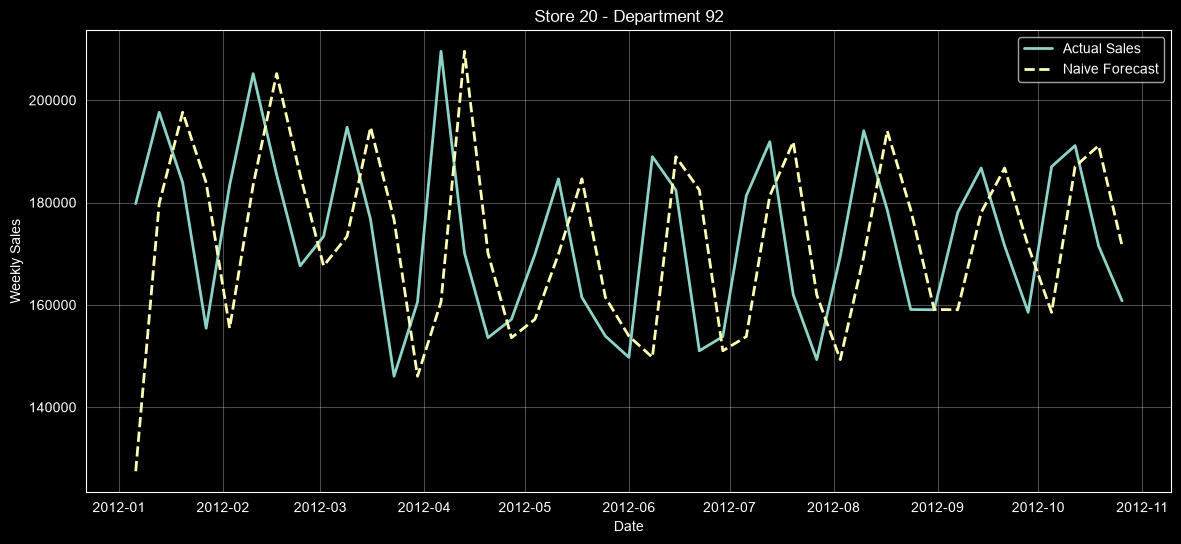

In [38]:
import matplotlib.pyplot as plt

store_id = 20
dept_id = 92

plot_df = test_df[
    (test_df["Store"] == store_id) &
    (test_df["Dept"] == dept_id)
].copy()

plot_df["Naive_Prediction"] = (
    X_test.loc[plot_df.index, "lag_1"]
)
plt.figure(figsize=(14, 6))

plt.plot(
    plot_df["Date"],
    plot_df["Weekly_Sales"],
    linewidth=2,
    label="Actual Sales"
)

plt.plot(
    plot_df["Date"],
    plot_df["Naive_Prediction"],
    linestyle="--",
    linewidth=2,
    label="Naive Forecast"
)

plt.title(f"Store {store_id} - Department {dept_id}")

plt.xlabel("Date")
plt.ylabel("Weekly Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

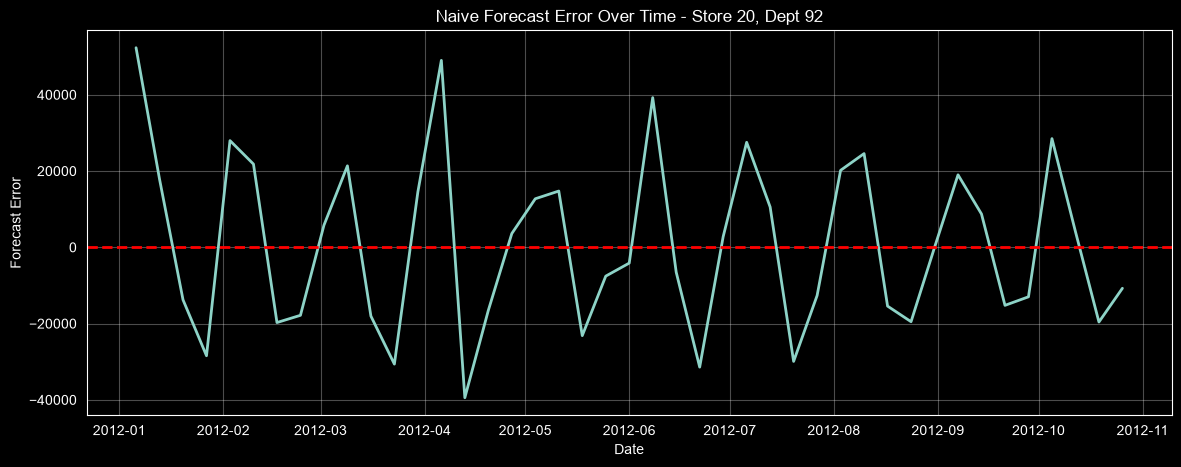

In [41]:
plot_df["Error"] = plot_df["Weekly_Sales"] - plot_df["Naive_Prediction"]

plt.figure(figsize=(14, 5))
plt.plot(plot_df["Date"], plot_df["Error"], linewidth=2)
plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Zero Error"
)
plt.title(f"Naive Forecast Error Over Time - Store {store_id}, Dept {dept_id}")
plt.xlabel("Date")
plt.ylabel("Forecast Error")
plt.grid(alpha=0.3)

plt.show()

The forecast errors fluctuate around zero, indicating that the simple forecasting model exhibits no systematic tendency to consistently overestimate or underestimate weekly sales.

However, positive and negative errors of relatively large magnitude do occur in certain weeks. These instances may reflect sudden fluctuations in demand—driven by holidays, promotions, or seasonal events that the model fails to capture when relying solely on prior weeks' sales data.